<a href="https://colab.research.google.com/github/hasanulazad-cloud/hasanul/blob/main/Smart_Mobility_%26_Ride_Analytics_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [76]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats
from statistics import mean, median, multimode
from scipy.stats import skew, kurtosis, ttest_1samp, chi2_contingency, f_oneway
from scipy.stats import f as f_dist
from statsmodels.stats.weightstats import ztest

In [44]:
url = 'https://github.com/GeethaGunasekaran1/Dataset_rep/raw/refs/heads/main/Trip_Analysis.xlsx'
df = pd.read_excel(url)
df.head()

,Trip_Distance,Fare_Amount,Ride_Category,Surge_Multiplier,Customer_Rating,Ride_Time
0,8,270.569350,Shared,2.5,3,Non-Peak
1,21,275.161032,Economy,2.5,3,Non-Peak
2,16,359.748971,Economy,2.0,5,Non-Peak
3,12,264.044264,Premium,1.5,5,Non-Peak
4,9,225.256916,Shared,2.0,2,Non-Peak


In [45]:
print(df.columns.tolist())

['Trip_Distance', 'Fare_Amount', 'Ride_Category', 'Surge_Multiplier', 'Customer_Rating', 'Ride_Time']


In [27]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 6 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Trip_Distance     200 non-null    int64  
 1   Fare_Amount       200 non-null    float64
 2   Ride_Category     200 non-null    object 
 3   Surge_Multiplier  200 non-null    float64
 4   Customer_Rating   200 non-null    int64  
 5   Ride_Time         200 non-null    object 
dtypes: float64(2), int64(2), object(2)
memory usage: 9.5+ KB


In [28]:
df.describe()

,Trip_Distance,Fare_Amount,Surge_Multiplier,Customer_Rating
count,200.000000,200.000000,200.000000,200.000000
mean,15.640000,260.312376,1.677500,2.930000
std,8.433625,78.706127,0.548862,1.444136
min,2.000000,37.585916,1.000000,1.000000
25%,8.000000,208.528826,1.000000,2.000000
50%,15.000000,256.907103,1.500000,3.000000
75%,23.000000,319.763782,2.000000,4.000000
max,29.000000,468.753773,2.500000,5.000000


In [29]:
#I.Data Preparation & Cleaning

In [50]:
# 1. Inspect missing values
print("Initial Missing Values:\n", df.isnull().sum())

# Clean missing numerical metrics using median and mean
df['Trip_Distance'] = df['Trip_Distance'].fillna(df['Trip_Distance'].median())
df['Fare_Amount'] = df['Fare_Amount'].fillna(df['Fare_Amount'].mean())

Initial Missing Values:
 Trip_Distance       0
Fare_Amount         0
Ride_Category       0
Surge_Multiplier    0
Customer_Rating     0
Ride_Time           0
dtype: int64


In [101]:
num_cols = ['Trip_Distance', 'Fare_Amount', 'Surge_Multiplier', 'Customer_Rating']
num_cols = df.select_dtypes(include=np.number).columns
df[num_cols] = df[num_cols].fillna(df[num_cols].mean())

cat_cols = ['Ride_Category', 'Ride_Time']
cat_cols = df.select_dtypes(include=object).columns
for col in cat_cols:
    df[col] = df[col].fillna(df[col].mode()[0])

In [31]:
# 2. Impute continuous columns using center metrics
if 'Trip_Distance' in df.columns:
    df['Trip_Distance'] = df['Trip_Distance'].fillna(df['Trip_Distance'].median())
if 'Fare_Amount' in df.columns:
    df['Fare_Amount'] = df['Fare_Amount'].fillna(df['Fare_Amount'].mean())


In [53]:
# 3. Clean structural anomalies
if 'Trip_Duration' in df.columns:
    df['Trip_Duration'] = df['Trip_Duration'].replace(0, np.nan)
    df['Trip_Duration'] = df['Trip_Duration'].fillna(df['Trip_Duration'].median())

if 'Ride_Time' in df.columns:
    ride_time_mode = df['Ride_Time'].mode()[0]
    df['Ride_Time'] = df['Ride_Time'].fillna(ride_time_mode)

print("Data cleaning completed successfully without TypeErrors.")

Data cleaning completed successfully without TypeErrors.


In [33]:
#II. Linear Algebra Concepts

In [34]:
# 1. Select the continuous feature columns
first_trip_vector = df[['Trip_Distance', 'Fare_Amount']].iloc[0].to_numpy()
print("Vector representation of the first trip:", first_trip_vector)

Vector representation of the first trip: [  8.        270.5693496]


In [35]:
# 2. Creating a Square Matrix
# We take the first 2 rows of Trip_Distance and Fare_Amount to build a 2x2 matrix
matrix_2x2 = df[['Trip_Distance', 'Fare_Amount']].iloc[0:2].to_numpy()
print("\nCreated 2x2 Matrix:\n", matrix_2x2)
matrix1 = features.cov().to_numpy()
print("matrix1:\n", matrix1)


Created 2x2 Matrix:
 [[  8.         270.5693496 ]
 [ 21.         275.16103167]]
matrix1:
 [[  71.12603015   11.16017252]
 [  11.16017252 6194.65446811]]


In [36]:
# 3. Computing the Determinant
# The matrix must be square (NxN) to compute a determinant
det = np.linalg.det(matrix_2x2)
print(f"\nDeterminant of the matrix: {det:.4f}")

if det == 0:
    print("The matrix is singular (it has no inverse).")
else:
    print("The matrix is non-singular (invertible).")


Determinant of the matrix: -3480.6681
The matrix is non-singular (invertible).


In [37]:
# 4. Compute Eigenvalues and Eigenvectors
# np.linalg.eig returns two arrays: one for eigenvalues, one for eigenvectors
eigenvalues, eigenvectors = np.linalg.eig(matrix1)

print(f"Eigenvalues (Magnitude of variance along new axes):\n {eigenvalues}")
print(f"\nEigenvectors (The directional axes/Principal Components):\n {eigenvectors}")

Eigenvalues (Magnitude of variance along new axes):
 [  71.10569073 6194.67480754]

Eigenvectors (The directional axes/Principal Components):
 [[-0.99999834 -0.0018225 ]
 [ 0.0018225  -0.99999834]]


In [38]:

# 5. Verification Check: A * v = lambda * v
# Multiplying the matrix by the first eigenvector should equal the first eigenvalue times the eigenvector
matrix_times_vector = np.dot(matrix1, eigenvectors[:, 0])
eigenvalue_times_vector = eigenvalues[0] * eigenvectors[:, 0]

print("\nVerification (Should match closely):")
print("Matrix * Vector:     ", matrix_times_vector)
print("Eigenvalue * Vector: ", eigenvalue_times_vector)


Verification (Should match closely):
Matrix * Vector:      [-71.10557264   0.12958996]
Eigenvalue * Vector:  [-71.10557264   0.12958996]


In [40]:
#III. Probablity Concepts

In [57]:
# Let's target the most common category in your dataset dynamically
target_category = df['Ride_Category'].mode()[0]
df['Is_Long_Distance'] = df['Trip_Distance'] > 5

In [65]:
# Basic Probability:
# P(Target Category)
p_category = (df['Ride_Category'] == target_category).mean()
# P(Long Distance)
p_long = df['Is_Long_Distance'].mean()
print(f"Basic Probability P(Ride_Category == '{target_category}'): {p_category:.4f}")
print(f"Basic Probability P(Long Distance): {p_long:.4f}")
# Conditional Probability: P(Long Distance | Target Category)
p_long_given_category = df[df['Ride_Category'] == target_category]['Is_Long_Distance'].mean()
print(f"Conditional Probability P(Long Distance | '{target_category}'): {p_long_given_category:.4f}")

Basic Probability P(Ride_Category == 'Economy'): 0.4100
Basic Probability P(Long Distance): 0.8450
Conditional Probability P(Long Distance | 'Economy'): 0.8415


In [66]:
# Bayes' Theorem: P(Target Category | Long Distance)
if p_long_given_category > 0:
    p_cat_given_long = (p_long_given_category * p_category) / p_long
    print(f"Basic P(Category={target_category}): {p_category:.4f}")
    print(f"Conditional P(Long | Category): {p_long_given_category:.4f}")
    print(f"Bayes' Updated P(Category | Long): {p_cat_given_long:.4f}")

Basic P(Category=Economy): 0.4100
Conditional P(Long | Category): 0.8415
Bayes' Updated P(Category | Long): 0.4083


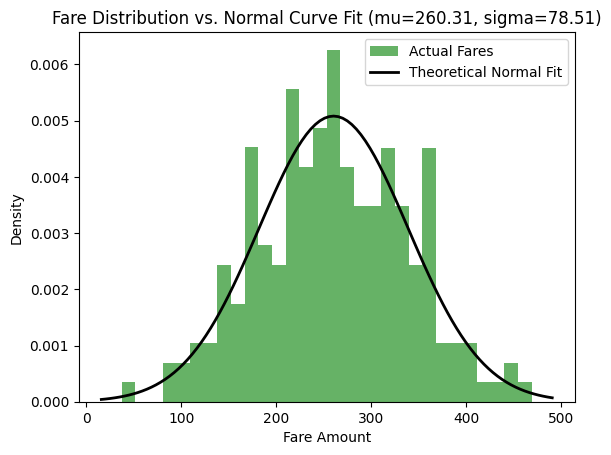

In [69]:
# Visualizing the Empirical Distribution against a Theoretical Normal Distribution
fare_data = df['Fare_Amount'].dropna()

# Fit a normal distribution to the data
mu, sigma = stats.norm.fit(fare_data)

# Plot histogram of the actual data
plt.hist(fare_data, bins=30, density=True, alpha=0.6, color='g', label='Actual Fares')

# Plot the theoretical normal curve over it
xmin, xmax = plt.xlim()
x = np.linspace(xmin, xmax, 100)
p = stats.norm.pdf(x, mu, sigma)
plt.plot(x, p, 'k', linewidth=2, label='Theoretical Normal Fit')

plt.title(f"Fare Distribution vs. Normal Curve Fit (mu={mu:.2f}, sigma={sigma:.2f})")
plt.xlabel("Fare Amount")
plt.ylabel("Density")
plt.legend()
plt.show()

In [74]:
# Descriptive Statistics (mean, median, mode, variance, standard deviation, skewness, kurtosis)
mean_value = df[num_cols].mean()
median_value = df[num_cols].median()
mode_value = df[cat_cols].mode()
variance_value = df[num_cols].var()
standard_deviation = df[num_cols].std()
skewness_value = df[num_cols].skew()
kurtosis_value = df[num_cols].kurtosis()

print(f"Mean (Averages):\n{mean_value}\n")
print(f"Median (Middle Values):\n{median_value}\n")
print(f"Mode (Most Frequent Text):\n{mode_value}\n")
print(f"Variance (Squared Spread):\n{variance_value}\n")
print(f"Standard Deviation (Spread):\n{standard_deviation}\n")
print(f"Skewness (Asymmetry):\n{skewness_value}\n")
print(f"Kurtosis (Tailedness):\n{kurtosis_value}\n")

Mean (Averages):
Trip_Distance        15.640000
Fare_Amount         260.312376
Surge_Multiplier      1.677500
Customer_Rating       2.930000
dtype: float64

Median (Middle Values):
Trip_Distance        15.000000
Fare_Amount         256.907103
Surge_Multiplier      1.500000
Customer_Rating       3.000000
dtype: float64

Mode (Most Frequent Text):
  Ride_Category Ride_Time
0       Economy      Peak

Variance (Squared Spread):
Trip_Distance         71.126030
Fare_Amount         6194.654468
Surge_Multiplier       0.301250
Customer_Rating        2.085528
dtype: float64

Standard Deviation (Spread):
Trip_Distance        8.433625
Fare_Amount         78.706127
Surge_Multiplier     0.548862
Customer_Rating      1.444136
dtype: float64

Skewness (Asymmetry):
Trip_Distance       0.052817
Fare_Amount         0.022837
Surge_Multiplier    0.156067
Customer_Rating     0.062733
dtype: float64

Kurtosis (Tailedness):
Trip_Distance      -1.270149
Fare_Amount        -0.251430
Surge_Multiplier   -1.295399

--- Seaborn Histogram ---


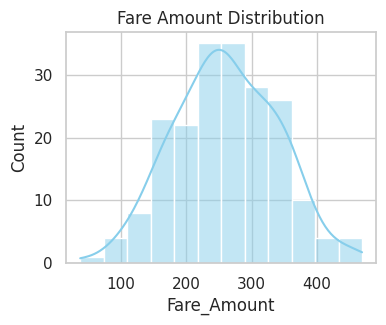

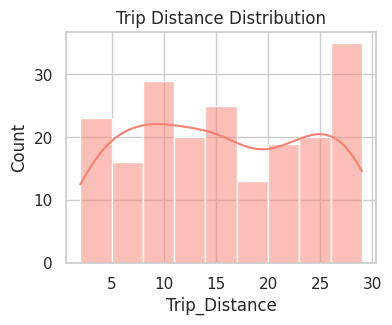

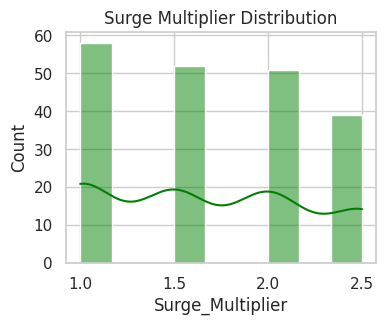

tasks executed successfully!


In [80]:
#VISUALIZATIONS
print("--- Seaborn Histogram ---")
sns.set_theme(style="whitegrid")

# Plot 1: Fare Amount Distribution
plt.figure(figsize=(4, 3))
sns.histplot(df['Fare_Amount'], kde=True, color="skyblue")
plt.title("Fare Amount Distribution")
plt.show()

# Plot 2: Trip Distance Distribution
plt.figure(figsize=(4, 3))
sns.histplot(df['Trip_Distance'], kde=True, color="salmon")
plt.title("Trip Distance Distribution")
plt.show()

# Plot 3: Surge Multiplier Distribution
plt.figure(figsize=(4, 3))
sns.histplot(df['Surge_Multiplier'], kde=True, color="green")
plt.title("Surge Multiplier Distribution")
plt.show()

print("tasks executed successfully!")

In [88]:
# OUTLIER DETECTION

data1 =  'Fare_Amount'

In [93]:
# METHOD A: PERCENTILES, QUARTILES, AND IQR

#Using Percentile

lower_percentile=np.percentile(df[data1],1)
print(f"lower bound: {lower_percentile}")
upper_percentile=np.percentile(df[data1],99)
print(f"upper bound: {upper_percentile}")

filtered_data = df[data1][(df[data1]>=lower_percentile)&(df[data1]<=upper_percentile)]

outliers_percentile = df[data1][(df[data1] < lower_percentile) | (df[data1] > upper_percentile)]
print(len(outliers_percentile))
print(outliers_percentile)

lower bound: 90.38119158607759
upper bound: 441.2429779984984
4
10     37.585916
17     88.214805
63    453.133017
94    468.753773
Name: Fare_Amount, dtype: float64


In [96]:
#Using Quartile

# 25th percentile
q1 = df[data1].quantile(0.25)
# 75th percentile
q3 = df[data1].quantile(0.75)

# Calculating IQR
iqr = q3 - q1

# Calculating Inner Fence Boundaries
lower_fence = q1 - 1.5 * iqr
upper_fence = q3 + 1.5 * iqr

# Filtering the Outliers
iqr_outliers = df[(df[data1] < lower_fence) | (df[data1] > upper_fence)]

print(f"\n--- IQR Method ---")
print(f"25th Percentile (Q1): {q1:.2f}")
print(f"75th Percentile (Q3): {q3:.2f}")
print(f"IQR Value: {iqr:.2f}")
print(f"Valid Range: [{lower_fence:.2f} to {upper_fence:.2f}]")
print(f"Number of Outliers Detected: {len(iqr_outliers)}")

clean_data=df[data1][((df[data1]>=lower_bound)&(df[data1]<=upper_bound))]


--- IQR Method ---
25th Percentile (Q1): 208.53
75th Percentile (Q3): 319.76
IQR Value: 111.23
Valid Range: [41.68 to 486.62]
Number of Outliers Detected: 1


In [97]:
# METHOD B: Z-SCORE METHOD

mean_val = df[data1].mean()
std_val = df[data1].std()

# Calculate Z-score for every row manually for clarity
df['Fare_Z_Score'] = (df[data1] - mean_val) / std_val

# Filter Outliers where absolute Z-score is greater than 3
z_outliers = df[np.abs(df['Fare_Z_Score']) > 3]

print(f"\n--- Z-Score Method ---")
print(f"Data Mean: {mean_val:.2f}")
print(f"Data Standard Deviation: {std_val:.2f}")
print(f"Number of Outliers Detected (|Z| > 3): {len(z_outliers)}")

# Print a preview of the highest outliers found
print("\nTop 5 Highest Outlier Fares Detected:")
print(df[[data1, 'Fare_Z_Score']].sort_values(by=data1, ascending=False).head())


--- Z-Score Method ---
Data Mean: 260.31
Data Standard Deviation: 78.71
Number of Outliers Detected (|Z| > 3): 0

Top 5 Highest Outlier Fares Detected:
     Fare_Amount  Fare_Z_Score
94    468.753773      2.648350
63    453.133017      2.449881
150   441.122877      2.297286
187   437.839754      2.255573
197   418.905411      2.015002


In [ ]:
# Measuring relationships using Pearson, Spearman, and covariance

In [103]:
# COVARIANCE

cov_value = df['Trip_Distance'].cov(df['Fare_Amount'])
print(df[['Trip_Distance', data1]].cov())
print(f"\nCovariance: {cov_value:.4f}")
if cov_value > 0:
    print("-> Direction: Positive relationship (Distance and Fare move up together).")
elif cov_value < 0:
    print("-> Direction: Negative relationship (As one moves up, the other moves down).")
else:
    print("-> Direction: No linear relationship.")

               Trip_Distance  Fare_Amount
Trip_Distance      71.126030    11.160173
Fare_Amount        11.160173  6194.654468

Covariance: 11.1602
-> Direction: Positive relationship (Distance and Fare move up together).


In [106]:
print(df[num_cols].cov())

                  Trip_Distance  Fare_Amount  Surge_Multiplier  \
Trip_Distance         71.126030    11.160173          0.079296   
Fare_Amount           11.160173  6194.654468          0.752497   
Surge_Multiplier       0.079296     0.752497          0.301250   
Customer_Rating       -1.030352     5.992595         -0.032739   
Fare_Z_Score           0.141795    78.706127          0.009561   

                  Customer_Rating  Fare_Z_Score  
Trip_Distance           -1.030352      0.141795  
Fare_Amount              5.992595     78.706127  
Surge_Multiplier        -0.032739      0.009561  
Customer_Rating          2.085528      0.076139  
Fare_Z_Score             0.076139      1.000000  


In [105]:
#PEARSON CORRELATION

pearson_r = df['Trip_Distance'].corr(df['Fare_Amount'], method='pearson')
print(f"\nPearson Correlation Coefficient (r): {pearson_r:.4f}")
print(f"-> Measures how close the data points sit to a perfect straight line.")


Pearson Correlation Coefficient (r): 0.0168
-> Measures how close the data points sit to a perfect straight line.


In [104]:
print(df[num_cols].corr(method='pearson'))

                  Trip_Distance  Fare_Amount  Surge_Multiplier  \
Trip_Distance          1.000000     0.016813          0.017131   
Fare_Amount            0.016813     1.000000          0.017419   
Surge_Multiplier       0.017131     0.017419          1.000000   
Customer_Rating       -0.084599     0.052723         -0.041304   
Fare_Z_Score           0.016813     1.000000          0.017419   

                  Customer_Rating  Fare_Z_Score  
Trip_Distance           -0.084599      0.016813  
Fare_Amount              0.052723      1.000000  
Surge_Multiplier        -0.041304      0.017419  
Customer_Rating          1.000000      0.052723  
Fare_Z_Score             0.052723      1.000000  


In [107]:
# SPEARMAN CORRELATION

spearman_rho = df['Trip_Distance'].corr(df['Fare_Amount'], method='spearman')
print(f"\nSpearman Rank Correlation Coefficient (rho): {spearman_rho:.4f}")
print(f"-> Measures if the variables increase together, regardless of whether it forms a straight line.")


Spearman Rank Correlation Coefficient (rho): 0.0234
-> Measures if the variables increase together, regardless of whether it forms a straight line.


In [108]:
print(df[num_cols].corr(method='spearman'))

                  Trip_Distance  Fare_Amount  Surge_Multiplier  \
Trip_Distance          1.000000     0.023427          0.025459   
Fare_Amount            0.023427     1.000000          0.011764   
Surge_Multiplier       0.025459     0.011764          1.000000   
Customer_Rating       -0.082067     0.047499         -0.047091   
Fare_Z_Score           0.023427     1.000000          0.011764   

                  Customer_Rating  Fare_Z_Score  
Trip_Distance           -0.082067      0.023427  
Fare_Amount              0.047499      1.000000  
Surge_Multiplier        -0.047091      0.011764  
Customer_Rating          1.000000      0.047499  
Fare_Z_Score             0.047499      1.000000  


In [111]:
#Applying Inferential Statistics (bootstrapping, CLT, point & interval estimation)

#BOOTSTRAPPING FOR THE CENTRAL LIMIT THEOREM

#Setting up a random seed so your results stay consistent each time you run it
np.random.seed(42)
#Creating an empty list to store the mean of each bootstrap sample
bootstrap_means = []
# Looping 1000 times to create 1000 simulated sample distributions
for i in range(1000):
# .sample(replace=True) takes a random shuffle where rows can repeat
    bootstrap_sample = df['Fare_Amount'].sample(n=len(df), replace=True)
# Calculate the mean of this single shuffle and save it
    sample_mean = bootstrap_sample.mean()
    bootstrap_means.append(sample_mean)
print(f"Successfully generated {len(bootstrap_means)} bootstrap sample means.")
print("According to the CLT, these means now follow a normal bell curve.\n")

Successfully generated 1000 bootstrap sample means.
According to the CLT, these means now follow a normal bell curve.



In [112]:
# POINT & INTERVAL ESTIMATION

# Point Estimate: The average of our bootstrapped means
point_estimate_mean = mean(bootstrap_means)

# Interval Estimate: 95% Confidence Interval
# We look for the cutoffs at the bottom 2.5% and the top 97.5% (leaving 95% in the middle)
ci_lower = np.percentile(bootstrap_means, 2.5)
ci_upper = np.percentile(bootstrap_means, 97.5)

print("--- Estimation Results ---")
print(f"Point Estimate (Best Guess for Mean Fare): ${point_estimate_mean:.2f}")
print(f"95% Confidence Interval: [${ci_lower:.2f} to ${ci_upper:.2f}]")
print(f"Interpretation: We are 95% confident that the true average fare of the entire population falls between ${ci_lower:.2f} and ${ci_upper:.2f}.")

--- Estimation Results ---
Point Estimate (Best Guess for Mean Fare): $260.16
95% Confidence Interval: [$248.51 to $270.79]
Interpretation: We are 95% confident that the true average fare of the entire population falls between $248.51 and $270.79.


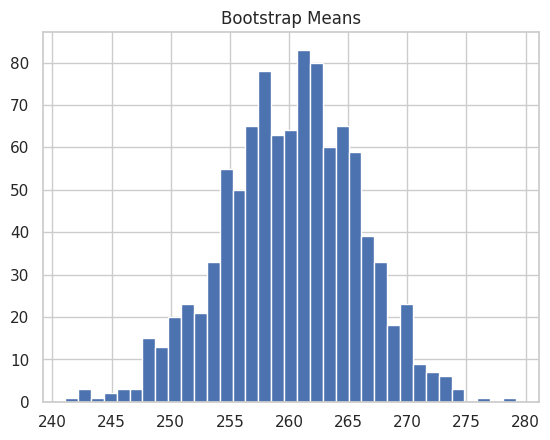

In [113]:
plt.hist(bootstrap_means,bins=35)
plt.title("Bootstrap Means")
plt.show()

In [119]:
# Extract target array for parametric testing
fare_data = df['Fare_Amount'].to_numpy()

# 1. PARAMETRIC TESTING SYSTEM (Means Comparison)

# H0: Population mean fare is exactly $15.00
historical_mu = 15.0
hypothesis_results = {}

# One-Sample T-test (Assumes unknown population variance)
t_stat, t_pval = stats.ttest_1samp(fare_data, popmean=historical_mu)
hypothesis_results['One-Sample T-test'] = {'statistic': t_stat, 'p-value': t_pval}

# Z-test (Large-sample asymptotic standard normal alternative)
z_stat, z_pval = ztest(fare_data, value=historical_mu)
hypothesis_results['Z-test'] = {'statistic': z_stat, 'p-value': z_pval}


# 2. CATEGORICAL DEPENDENCY SYSTEM (Independence Testing)

# H0: Ride_Category choice is independent of trip distance classification
contingency_matrix = pd.crosstab(df['Ride_Category'], df['Is_Long_Distance'])

chi2_stat, chi2_pval, dof, expected = stats.chi2_contingency(contingency_matrix)
hypothesis_results['Chi-Square Test'] = {'statistic': chi2_stat, 'p-value': chi2_pval}


# 3. VARIANCE SIMULACRUM SYSTEM (ANOVA A/B TESTING Engine)

# H0: Mean Fare_Amount is homogeneous across all variations of Ride_Category
# Group data dynamically by stripping text subsets out into distinct NumPy vectors
anova_groups = [
    group['Fare_Amount'].to_numpy()
    for name, group in df.groupby('Ride_Category')
    if len(group) > 1
]

if len(anova_groups) > 1:
    f_stat, anova_pval = stats.f_oneway(*anova_groups)
    hypothesis_results['ANOVA F-test'] = {'statistic': f_stat, 'p-value': anova_pval}

    # Mathematical Critical Boundary Evaluation via the F-Distribution
    df_between = len(anova_groups) - 1
    df_within = len(df) - len(anova_groups)
    f_critical = stats.f.ppf(q=1-0.05, dfn=df_between, dfd=df_within)
    print(f"--- F-Distribution Boundary Profiles ---")
    print(f"Degrees of Freedom: Between Groups ({df_between}), Within Groups ({df_within})")
    print(f"Calculated F-Stat: {f_stat:.4f} | Critical Cutoff Threshold: {f_critical:.4f}\n")


# 4. REPORTING & METRIC EVALUATION ENGINE

print("--- Execution Summary Report ---")
alpha = 0.05

for test_name, metrics in hypothesis_results.items():
    stat = metrics['statistic']
    p_val = metrics['p-value']

    # Establish dynamic decision output
    status = "REJECT H0" if p_val < alpha else "FAIL TO REJECT H0"

    print(f"{test_name:17} -> Stat: {stat:8.4f} | p-value: {p_val:8.6f} | Decision: {status}")

--- F-Distribution Boundary Profiles ---
Degrees of Freedom: Between Groups (2), Within Groups (197)
Calculated F-Stat: 0.9285 | Critical Cutoff Threshold: 3.0418

--- Execution Summary Report ---
One-Sample T-test -> Stat:  44.0784 | p-value: 0.000000 | Decision: REJECT H0
Z-test            -> Stat:  44.0784 | p-value: 0.000000 | Decision: REJECT H0
Chi-Square Test   -> Stat:   0.1992 | p-value: 0.905198 | Decision: FAIL TO REJECT H0
ANOVA F-test      -> Stat:   0.9285 | p-value: 0.396869 | Decision: FAIL TO REJECT H0
